In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#getting my data ready used in machine learning

#   - split the data into features ( X and Y) 
#   - filling missing the missing values
#   - converting non-numerical values to numerical values also called feature encoding



In [3]:
heart_desease = pd.read_csv("heart-disease.csv")
heart_desease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
x = heart_desease.drop("target", axis=1)
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [5]:
y = heart_desease["target"]
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [6]:
#split the data into training and test sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2)

In [7]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [8]:
#Make sure its all numerical
car_sales = pd.read_csv("car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [9]:
len(car_sales)

1000

In [10]:
car_sales.dtypes

Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

In [11]:
car_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Make           1000 non-null   object
 1   Colour         1000 non-null   object
 2   Odometer (KM)  1000 non-null   int64 
 3   Doors          1000 non-null   int64 
 4   Price          1000 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 39.2+ KB


In [12]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043
...,...,...,...,...,...
995,Toyota,Black,35820,4,32042
996,Nissan,White,155144,3,5716
997,Nissan,Blue,66604,4,31570
998,Honda,White,215883,4,4001


In [13]:
X = car_sales.drop("Price",axis=1)
Y = car_sales["Price"]

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()

from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)
model.fit(X_train,Y_train)
model.score(X_test,Y_test)

ValueError: could not convert string to float: 'Honda'

In [20]:
#change the categorical values into numerical
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_feature = ["Make","Colour","Doors"]

one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_feature,
                                  )], remainder ="passthrough",)

transfomed_x = transformer.fit_transform(X)
transfomed_x


array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

In [21]:
X.head(3)

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431,4
1,BMW,Blue,192714,5
2,Honda,White,84714,4


In [22]:
pd.DataFrame(transfomed_x)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [23]:
dummies = pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [24]:
#Lets refit the model

np.random.seed(42)
X_train,X_test,Y_train,Y_test = train_test_split(transfomed_x,Y, test_size=0.2)
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
model.score(X_test,Y_test)

0.3235867221569877

In [ ]:
# ### What if there's missing values
#     1. Fill them with some value
#     2. Removing samples with missing data together 

In [ ]:
#import car sales with missing data
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")
len(car_sales_missing)


1000

In [ ]:
X = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing["Price"]

In [25]:
#convert data to numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_feature = ["Make","Colour","Doors"]

one_hot = OneHotEncoder()
transfomer = ColumnTransformer([("one_hot",
                                   one_hot,
                                   categorical_feature)],
                                   remainder="passthrough")

transfomed_x = transfomer.fit_transform(X)

In [ ]:

###fill missing data with pandas 


In [27]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")

#fill the make column
car_sales_missing["Make"].fillna("missing", inplace=True)

#fill the Colour column
car_sales_missing["Colour"].fillna("missing", inplace=True)

#fill the Odomoter (KM) column
car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean(), inplace=True)

#fill the Doors column
car_sales_missing["Doors"].fillna(4, inplace=True)

/tmp/ipykernel_1852236/1268362743.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_sales_missing["Make"].fillna("missing", inplace=True)
/tmp/ipykernel_1852236/1268362743.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [28]:
car_sales_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [ ]:
car_sales_missing.dropna(inplace=True)
car_sales_missing.isna().sum()

773

In [ ]:
len(car_sales_missing)

773

In [29]:
X = car_sales_missing.drop("Price", axis=1)
Y = car_sales_missing["Price"]

#convert data to numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_feature = ["Make","Colour","Doors"]

one_hot = OneHotEncoder()
transfomer = ColumnTransformer([("one_hot",
                                   one_hot,
                                   categorical_feature)],
                                   remainder="passthrough")

transfomed_x = transfomer.fit_transform(car_sales_missing)
transfomed_x



array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(1000, 16))

In [ ]:
### Fill missing values with sklearn


In [30]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [31]:
#drop rows with no labels
car_sales_missing.dropna(subset=["Price"], inplace=True)

X = car_sales_missing.drop("Price", axis=1)
Y = car_sales_missing["Price"]

In [32]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

#Fill categorical values with 'missing' and numerical values with 'mean' 
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

#Define columns
cat_features = ["Make","Colour"]
door_feature = ["Doors"]
num_features = ["Odometer (KM)"]

#Create an imputer -> something that fills missing data
imputer = ColumnTransformer([
    ("cat_imputer", cat_imputer,cat_features),
    ("door_imputer",door_imputer,door_feature),
    ("num_imputer", num_imputer, num_features)
])

#Transform the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [35]:
car_sales_filled = pd.DataFrame(filled_X, columns=["Make","Colour","Doors","Odometer (KM)"])
car_sales_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [ ]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [36]:
#change to numbers 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_feature = ["Make","Colour","Doors"]

one_hot = OneHotEncoder()
transfomer = ColumnTransformer([("one_hot",
                                   one_hot,
                                   categorical_feature)],
                                   remainder="passthrough")

transfomed_x = transfomer.fit_transform(car_sales_filled)
transfomed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

In [37]:
np.random.seed(90)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

x_train,x_test,y_train,y_test = train_test_split(transfomed_x,Y, test_size=0.2)

model.fit(x_train,y_train)
model.score(x_test,y_test)

0.2412734101275903

In [ ]:
len(car_sales_filled), len(car_sales)

(950, 1000)

In [ ]:
### Choosing the right estimator /Algorithm for your problem

In [ ]:
## picking machine learning model for regression models 

In [38]:
#Get data from california dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [40]:
housing_Df = pd.DataFrame(housing['data'], columns=housing["feature_names"])
housing_Df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [41]:
housing_Df["target"] = housing["target"]
housing_Df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
#import the algothim
from sklearn.linear_model import Ridge
np.random.seed(42)

x = housing_Df.drop("target", axis=1)
y = housing_Df["target"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

#fit the model
model = Ridge()
model.fit(x_train,y_train)
model.score(x_test,y_test)




0.5758549611440126

In [42]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_desease.drop("target", axis=1)
Y = heart_desease["target"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)
clf = RandomForestClassifier(n_estimators=100)

clf.fit(X_train,Y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
clf.score(X_test,Y_test)

0.8524590163934426

In [45]:
cross_val_score(clf, X,Y, cv=10)

array([0.90322581, 0.80645161, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.73333333, 0.86666667, 0.73333333, 0.8       ])

In [47]:
"""
classification model evaluation metrics
1. Accuracy
2. Area under the receiver operating characteristic curve (AUC/ROC)
3. Confusion matrix
4. Classification report
"""

'\nclassification model evaluation metrics\n1. Accuracy\n2. Area under the receiver operating characteristic curve (AUC/ROC)\n3. Confusion matrix\n4. Classification report\n'

In [53]:
# 1. Accuracy
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_desease.drop("target", axis=1)
Y = heart_desease["target"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)
clf = RandomForestClassifier(n_estimators=100)

cross_value_scores = cross_val_score(clf, X,Y, cv=5)


In [54]:
np.mean(cross_value_scores)

np.float64(0.8215300546448088)

In [55]:
print(f"Heart desease classifier cross validation accuracy: {np.mean(cross_value_scores)*100:.2f}%")

Heart desease classifier cross validation accuracy: 82.15%


In [57]:
#2. Area under the receiver operating characteristic curve (AUC/ROC)

"""
 ROC - Is the comparison of a model's true positive rate (tpr) versus a model's false positive rate (fpr)
   .True positive = model predicts 1 when truth is 1
   .False positive = model predicts 1 when truth is 0
   .True negative = model predicts 0 when truth is 0
   .False negative = model predicts 0 when truth is 1
"""
 

"\n ROC - Is the comparison of a model's true positive rate (tpr) versus a model's false positive rate (fpr)\n   .True positive = model predicts 1 when truth is 1\n   .False positive = model predicts 1 when truth is 0\n   .True negative = model predicts 0 when truth is 0\n   .False negative = model predicts 0 when truth is 1\n"

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
np.random.seed(42)
X = heart_desease.drop("target", axis=1)
Y = heart_desease["target"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)
clf = RandomForestClassifier(n_estimators=100)

#make predictions with probabilities
y_probs = clf.fit(X_train,Y_train).predict_proba(X_test)
y_probs[:10], len(y_probs), y_probs.shape

(array([[0.89, 0.11],
        [0.49, 0.51],
        [0.43, 0.57],
        [0.84, 0.16],
        [0.18, 0.82],
        [0.14, 0.86],
        [0.36, 0.64],
        [0.95, 0.05],
        [0.99, 0.01],
        [0.47, 0.53]]),
 61,
 (61, 2))

In [63]:
y_probs_positive = y_probs[:,1]
y_probs_positive[:10]

array([0.11, 0.51, 0.57, 0.16, 0.82, 0.86, 0.64, 0.05, 0.01, 0.53])

In [ ]:
#calculate fpr, tpr and thresholds
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(Y_test, y_probs_positive)

#check the false positive 
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.03448276, 0.03448276, 0.03448276, 0.03448276, 0.06896552,
       0.06896552, 0.10344828, 0.13793103, 0.13793103, 0.17241379,
       0.17241379, 0.27586207, 0.4137931 , 0.48275862, 0.55172414,
       0.65517241, 0.72413793, 0.72413793, 0.82758621, 1.        ])

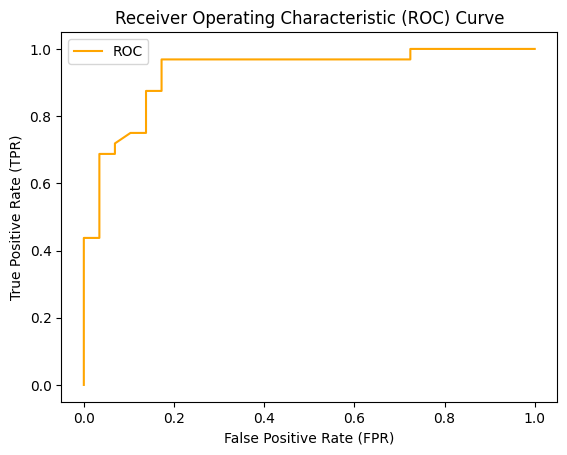

In [70]:
#create a function for plotting ROC curve
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the false positive rate (fpr) and true positive rate (tpr).
    """
    plt.plot(fpr, tpr, color="orange", label="ROC")
    # plt.plot([0, 1], [0, 1], color="darkblue", linestyle="--", label="Guessing")

    #customize the plot
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr, tpr)

In [69]:
from sklearn.metrics import roc_auc_score
roc_auc_score(Y_test, y_probs_positive)

0.9304956896551724

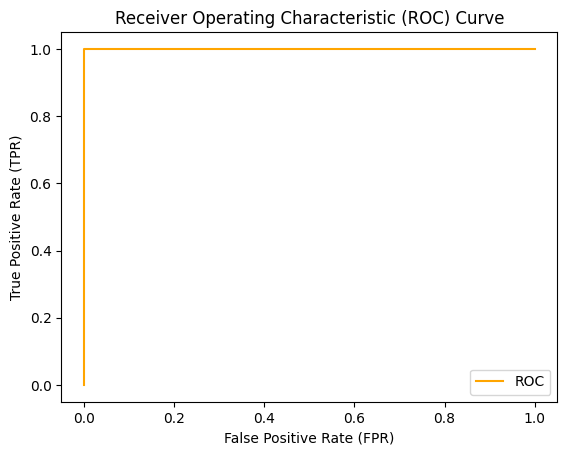

In [73]:
#plot perfect ROC curve and AUC score
fpr,tpr, thresholds = roc_curve(Y_test,Y_test)
roc_auc_score(Y_test, y_probs_positive)
plot_roc_curve(fpr, tpr)

In [75]:
#perfect AUC score is 1.0, the closer to 1.0 the better the model is at predicting positive class
roc_auc_score(Y_test, Y_test)

1.0

In [76]:
"""
Confusion matrix
A confusion matrix is a table that is often used to describe the performance of a classification model (
- it is used to compare the actual values with the predicted values by the model). 
  It is a table with 4 different combinations of predicted and actual values.
"""

'\nConfusion matrix\nA confusion matrix is a table that is often used to describe the performance of a classification model (\n- it is used to compare the actual values with the predicted values by the model). \n  It is a table with 4 different combinations of predicted and actual values.\n'

In [77]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(X_test)
confusion_matrix(Y_test, y_preds)

array([[24,  5],
       [ 4, 28]])

In [78]:
#visualize confusion matrix with pd.crosstab()
pd.crosstab(Y_test,
            y_preds,
            rownames=["Actual Labels"],
            colnames=["Predicted Labels"])


Predicted Labels,0,1
Actual Labels,,
0,24,5
1,4,28


In [79]:
len(X_test), len(Y_test), len(y_preds)

(61, 61, 61)

<Axes: >

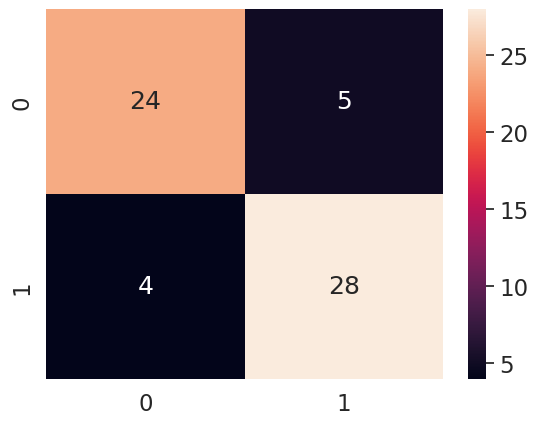

In [80]:
# set the confusion matrix visualization with seaborn
import seaborn as sns

#set the font scale and style
sns.set(font_scale=1.5)

#create a confusion matrix
confusion_matrix = confusion_matrix(Y_test, y_preds)
sns.heatmap(confusion_matrix, annot=True, fmt='d')